Лабораторная работа 6 Итоговый аналитический мини проект

Цель: Объединить все этапы анализа данных и машинного обучения в одном проекте

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("finish_laba5.csv")
df.head()

,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,...,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_per_flight,total_delay
0,2022,7,9E,ABE,33.0,2.0,0.92,1.00,0.08,0.0,...,0.0,0.0,129.0,98.0,23.0,8.0,0.0,0.0,3.794118,129.0
1,2022,7,9E,ABY,78.0,25.0,11.80,0.72,5.01,0.0,...,0.0,0.0,1664.0,887.0,52.0,224.0,0.0,501.0,21.063291,1664.0
2,2022,7,9E,ACK,124.0,19.0,5.84,1.00,6.76,0.0,...,5.0,4.0,1523.0,388.0,35.0,511.0,0.0,589.0,12.184000,1523.0
3,2022,7,9E,AEX,67.0,10.0,1.32,1.00,2.40,1.0,...,0.0,1.0,657.0,103.0,82.0,93.0,25.0,354.0,9.661765,632.0
4,2022,7,9E,AGS,174.0,30.0,18.10,5.75,3.60,0.0,...,1.0,0.0,2462.0,1686.0,310.0,139.0,0.0,327.0,14.068571,2462.0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 88752 entries, 0 to 88751
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 88752 non-null  int64  
 1   month                88752 non-null  int64  
 2   carrier              88752 non-null  str    
 3   airport              88752 non-null  str    
 4   arr_flights          88752 non-null  float64
 5   arr_del15            88752 non-null  float64
 6   carrier_ct           88752 non-null  float64
 7   weather_ct           88752 non-null  float64
 8   nas_ct               88752 non-null  float64
 9   security_ct          88752 non-null  float64
 10  late_aircraft_ct     88752 non-null  float64
 11  arr_cancelled        88752 non-null  float64
 12  arr_diverted         88752 non-null  float64
 13  arr_delay            88752 non-null  float64
 14  carrier_delay        88752 non-null  float64
 15  weather_delay        88752 non-null  float64
 1

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_per_flight,total_delay
count,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000,88752.000000
mean,2019.546703,6.287385,125.950086,19.024890,7.238747,0.796659,4.972413,0.052979,5.964142,3.704345,0.277244,1156.373828,458.129068,79.162948,204.370369,2.443517,412.265515,10.174857,1153.927900
std,1.535892,3.458985,170.915966,21.248104,8.735959,1.442031,7.195283,0.303511,8.073994,32.555725,0.907566,1293.930220,571.466066,191.779550,327.331165,17.090677,568.043333,9.535851,1291.367602
min,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,3.000000,33.000000,4.000000,1.450000,0.000000,0.540000,0.000000,0.800000,0.000000,0.000000,217.000000,67.000000,0.000000,17.000000,0.000000,25.000000,4.071429,216.000000
50%,2020.000000,6.000000,76.000000,11.000000,4.130000,0.000000,2.450000,0.000000,2.980000,0.000000,0.000000,669.000000,238.000000,0.000000,89.000000,0.000000,182.000000,8.087719,667.000000
75%,2021.000000,9.000000,151.000000,26.000000,9.730000,1.000000,6.370000,0.000000,7.990000,2.000000,0.000000,1629.000000,636.000000,73.000000,252.000000,0.000000,558.000000,13.770982,1624.000000
max,2022.000000,12.000000,5322.000000,183.000000,127.660000,28.000000,112.410000,26.070000,86.390000,2839.000000,106.000000,5888.000000,5298.000000,4483.000000,5648.000000,1132.000000,5333.000000,356.000000,5888.000000


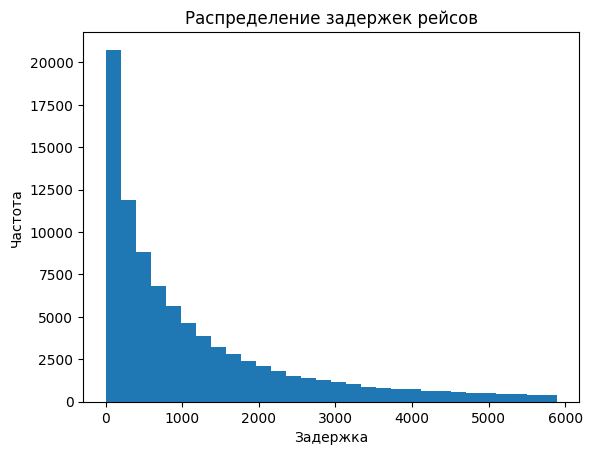

In [5]:
plt.hist(df["arr_delay"], bins=30)
plt.title("Распределение задержек рейсов")
plt.xlabel("Задержка")
plt.ylabel("Частота")
plt.show()

Общий анализ данных EDA

In [11]:
X = df.drop(columns=["arr_delay"]).select_dtypes(include=['number'])
y = df["arr_delay"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Разделение данных

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

Linear Regression

In [13]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

Decision Tree

In [14]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

Random Forest

In [15]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_tree),
        mean_absolute_error(y_test, pred_rf)
    ],
    "MSE": [
        mean_squared_error(y_test, pred_lr),
        mean_squared_error(y_test, pred_tree),
        mean_squared_error(y_test, pred_rf)
    ],
    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_tree),
        r2_score(y_test, pred_rf)
    ]
})

results

,Model,MAE,MSE,R2
0,Linear Regression,0.170998,0.336653,1.000000
1,Decision Tree,1.083601,80.317560,0.999951
2,Random Forest,0.725154,63.890783,0.999961


Сравнение моделей

In [16]:
param_grid = {
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

Подбор гиперпараметров

In [17]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
17,total_delay,9.998364e-01
14,security_delay,1.315833e-04
7,security_ct,1.816382e-05
3,arr_del15,3.266527e-06
16,delay_per_flight,2.591999e-06
6,nas_ct,1.257075e-06
4,carrier_ct,7.960880e-07
12,weather_delay,7.401154e-07
15,late_aircraft_delay,6.446597e-07
8,late_aircraft_ct,6.313299e-07


Интерпретация модели

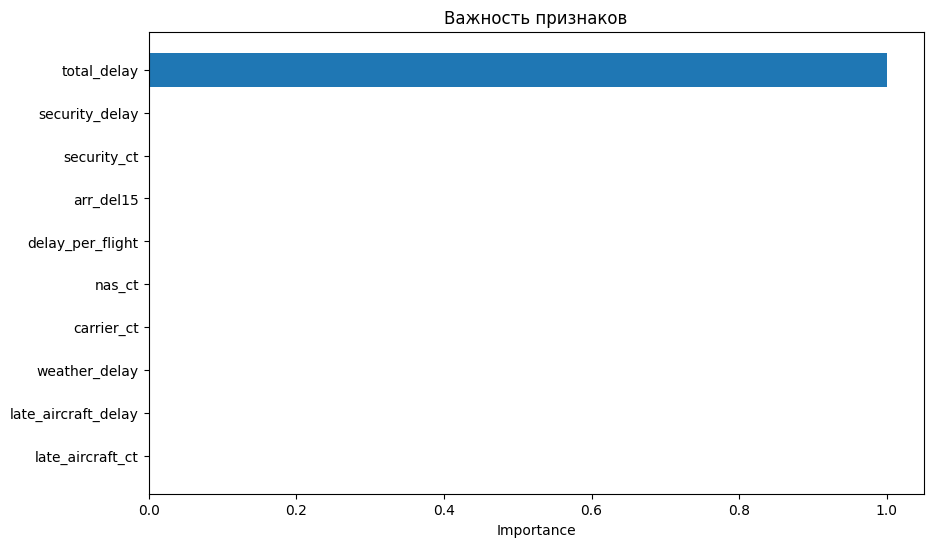

In [18]:
top = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top["Feature"][::-1], top["Importance"][::-1])
plt.title("Важность признаков")
plt.xlabel("Importance")
plt.show()

Визуализация. Определяются ключевые факторы, влияющие на задержки рейсов

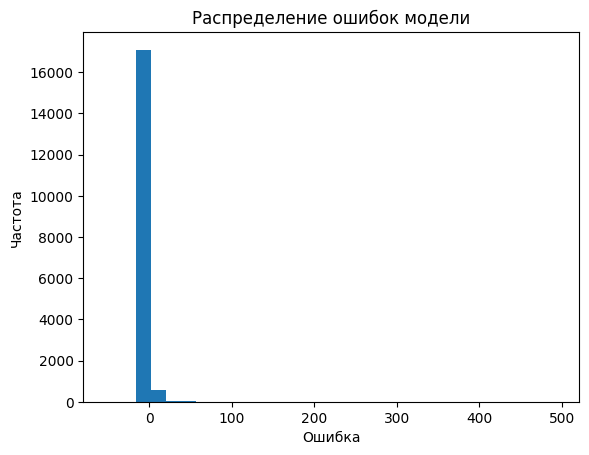

In [19]:
errors = y_test - pred_rf

plt.hist(errors, bins=30)
plt.title("Распределение ошибок модели")
plt.xlabel("Ошибка")
plt.ylabel("Частота")
plt.show()

Анализ ошибок модели

Вывод:
Проведено обучение нескольких моделей машинного обучения
Выполнено сравнение моделей по метрикам качества
Проведён подбор гиперпараметров
Выполнен анализ важности признаков
Проведён анализ ошибок модели

Практическое приминение:
Прогнозирования задержек рейсов
Оптимизация расписания авиаперевозок
Анализа факторов, влияющих на задержки
Повышения качества планирования рейсов